In [1]:

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
from torch import optim
import torchvision.transforms.functional as F
from torchvision import datasets, transforms

In [2]:
DEVICE = torch.device("mps" if torch.mps.is_available() else 'cpu')

In [3]:
train_dataset = datasets.EMNIST(
    root ='./data',
    split='letters',
    train= True,
    download=True,
)

In [4]:
test_dataset = datasets.EMNIST(
    root ='./data',
    split = 'letters',
    train= False,
    download= True
)

In [5]:
def correct_image_orientation(image):
    rotated = F.rotate(image,90)
    flipped = F.vflip(rotated)
    return flipped

In [6]:
mean = (0.1736,)
std = (0.3317,)

transform = transforms.Compose([
    transforms.ToTensor(),
    lambda x: correct_image_orientation(x),
    transforms.Normalize(mean= mean, std = std)
])

In [7]:
train_dataset.transform = transform
test_dataset.transform = transform

In [8]:
img_tensor, label = train_dataset[40000]

### Shape of the img_tensor

In [9]:
print(img_tensor.shape)

torch.Size([1, 28, 28])


In [10]:
img_transformed = correct_image_orientation(img_tensor)

In [11]:
def convert_emnist_label_to_char(label):
    if not ( 1 <= label <= 26):
        raise ValueError("Label must be between 1 and 26 inclusive")

    upper_char = chr(64 + label)

    lower_char = chr(96 + label)

    char_tuple = (upper_char, lower_char)

    return char_tuple

In [12]:
def visualize_image(img, label=None, ax=None):
    if isinstance(img, torch.Tensor):
        img = img.numpy().squeeze()
    elif isinstance(img, np.ndarray):
        if img.ndim == 3:
            img = img[:,:,0]

    if label is not None:
        upper_case_char, lower_case_char = convert_emnist_label_to_char(label)
        title = f"EMNIST Letter: {upper_case_char}/{lower_case_char}"
    else:
        title = None

    if ax is None:
        fig,ax = plt.subplots(figsize=(5,5))
        show_colorbar = True

    else:
        show_colorbar = False

    im = ax.imshow(img, cmap='gray')

    ax.set_xticks(np.arange(0,28,1))
    ax.set_yticks(np.arange(0, 28, 1))
    ax.tick_params(labelsize=6)
    ax.grid(True, color="red", alpha=0.3)

    if title:
        ax.set_title(title)

    if show_colorbar:
        plt.colorbar(im, ax=ax)

    plt.show()


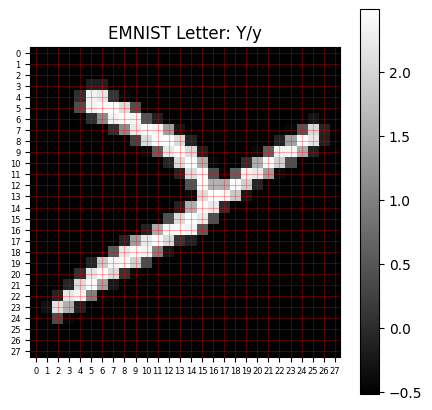

In [13]:
visualize_image(img_transformed, label)

### Loading Data

In [14]:
def create_emnist_dataloaders(train_dataloader, test_dataloader, batch_size=64):

    train_dataloader = DataLoader(
        train_dataloader,
        batch_size = batch_size,
        shuffle= True
    )

    test_dataloader = DataLoader(
        test_dataloader,
        batch_size = batch_size,
        shuffle = False
    )

    return train_dataloader, test_dataloader


In [15]:
train_loader, test_loader = create_emnist_dataloaders(train_dataset,test_dataset, batch_size=64)

In [16]:
def display_data_loader_contents(data_loader):

    try:
        print("Total number of images in dataset:", len(data_loader.dataset))
        print("Total number of batches:", len(data_loader))

        for batch_idx, (data, labels) in enumerate(data_loader):
            print(f"--- Batch {batch_idx + 1} ---")
            print(f"Data shape: {data.shape}")
            print(f"Label shape: {labels.shape}")
            break

    except StopIteration:
        print("data loader is empty")
    except Exception as err:
        print(f"And error occurred: {err}")

In [17]:
print("--- Train Loader ---\n")
display_data_loader_contents(train_loader)
print("--- Test Loader ---\n")
display_data_loader_contents(test_loader)

--- Train Loader ---

Total number of images in dataset: 124800
Total number of batches: 1950
--- Batch 1 ---
Data shape: torch.Size([64, 1, 28, 28])
Label shape: torch.Size([64])
--- Test Loader ---

Total number of images in dataset: 20800
Total number of batches: 325
--- Batch 1 ---
Data shape: torch.Size([64, 1, 28, 28])
Label shape: torch.Size([64])


### Neural Network

In [18]:
def initialize_emnist_model(num_classes=26):
    torch.manual_seed(42)

    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(784,256),
        nn.ReLU(),
        nn.Linear(256,128),
        nn.ReLU(),
        nn.Linear(128, num_classes)
    )

    loss_function = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters())

    return model, loss_function, optimizer

In [19]:
model, loss_function, optimizer = initialize_emnist_model(num_classes=26)

In [20]:
print(f"model's architecture:\n\n{model}\n")
print(f"model's loss function: {loss_function}\n")
print(f"model's optimizer:\n\n{optimizer}\n")

model's architecture:

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=128, bias=True)
  (4): ReLU()
  (5): Linear(in_features=128, out_features=26, bias=True)
)

model's loss function: CrossEntropyLoss()

model's optimizer:

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)



In [21]:
def train_epoch(model, loss_function, optimizer, train_loader, device, verbose=True):

    model.to(device)
    model.train()

    running_loss = 0.0
    num_correct_predictions = 0
    total_predictions = 0

    for batch_idx, (inputs, targets) in enumerate(train_loader):
        inputs, targets = inputs.to(device),  targets.to(device)

        targets = (targets - 1).long()

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_function(outputs, targets)

        loss.backward()

        optimizer.step()

        loss_value = loss.item()
        running_loss  += loss_value

        predicted_indices = outputs.argmax(dim=1)
        correct_predictions = (predicted_indices == targets)
        num_correct_in_batch = correct_predictions.sum().item()
        num_correct_predictions += num_correct_in_batch

        batch_size = targets.size(0)
        total_predictions += batch_size

    average_loss = running_loss / len(train_loader)
    accuracy_percentage = (num_correct_predictions / total_predictions) * 100

    if verbose:
        print(f"Epoch Loss (Avg): {average_loss:.3f}| Epoch Acc: {accuracy_percentage:.2f}%")


    return model, average_loss


### Sanity Check

In [22]:
model, loss_function, optimizer = initialize_emnist_model(num_classes=26)

In [23]:

model_one_train_epoch, _ = train_epoch(model=model, # model
                                       loss_function=loss_function, # loss_function
                                       optimizer=optimizer, # optimizer
                                       train_loader=train_loader, # train_loader
                                       device=DEVICE) # DEVICE

Epoch Loss (Avg): 0.605| Epoch Acc: 81.45%


### Model Evaluation

In [24]:
def evaluate(model, test_loader, device, verbose=True):


    # Set the model to evaluate mode
    model.eval()
    # Initialize the number of correct predictions to 0
    num_correct_predictions = 0
    # Initialize the total number of predictions to 0
    total_predictions = 0

    ### START CODE HERE ###

    # Use torch.no_grad() context to disable gradient calculations during evaluation.
    with torch.no_grad():

    ### END CODE HERE ###

        # Iterate over the batches of data from the test DataLoader
        for inputs, targets in test_loader:
            # Move the inputs and targets to the specified device
            inputs, targets = inputs.to(device), targets.to(device)

            # Shift target labels down by 1 (adjusting for EMNIST letters dataset)
            targets = (targets - 1).long()

        ### START CODE HERE ###

            # Pass the inputs through the model to get the outputs.
            outputs = model(inputs)

            # Get the predicted indices (by taking the argmax along dimension 1 of the outputs).
            predicted_indices =  outputs.argmax(dim=1)

            # Compare predicted indices to actual targets
            correct_predictions = (predicted_indices == targets)

            # Sum of correct predictions in the current batch.
            num_correct_in_batch = correct_predictions.sum().item()

            # Add correct predictions to the total correct predictions.
            num_correct_predictions += (num_correct_in_batch)

            # Get the batch size from the targets and add it to total predictions.
            batch_size = targets.size(0)
            total_predictions += batch_size

        ### END CODE HERE ###

        # Calculate the accuracy percentage. Multiply correct predictions by 100.
        accuracy_percentage = (num_correct_predictions / total_predictions) * 100

    if verbose:  # Conditionally print based on verbose flag
        print((f'Test Accuracy: {accuracy_percentage:.2f}%'))

    return accuracy_percentage

In [25]:
def train_and_evaluate(model, train_loader, test_loader, num_epochs, loss_function, optimizer, device, patience = 5):


    best_accuracy = 0.0
    epochs_without_improvement = 0
    best_model_state = None

    for epoch in range(num_epochs):
        print(f"\nEpoch:{epoch + 1}")

        trained_model, _ = train_epoch(model, loss_function, optimizer, train_loader, device)

        accuracy = evaluate(model, test_loader, device)

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            epochs_without_improvement = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            epochs_without_improvement +=  1
            print(f"Noe improvement for {epochs_without_improvement}/{patience} epochs")

        if epochs_without_improvement >= patience:
            print(f"\nEarly stopping triggered. Best accuracy: {best_accuracy:.2f}%")
            break
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model

In [26]:
num_epochs = 1000

In [27]:
if num_epochs > 1000 or num_epochs < 1:
    print(f"\033[91mSet num_epochs between 1 and 1000 (inclusive)")

else:
    emnist_model, loss_function, optimizer = initialize_emnist_model(num_classes=26)

    trained_model = train_and_evaluate(
        model = emnist_model,
        train_loader= train_loader,
        test_loader = test_loader,
        num_epochs= num_epochs,
        loss_function= loss_function,
        optimizer= optimizer,
        device= DEVICE
    )


Epoch:1
Epoch Loss (Avg): 0.605| Epoch Acc: 81.45%
Test Accuracy: 87.27%

Epoch:2
Epoch Loss (Avg): 0.328| Epoch Acc: 89.34%
Test Accuracy: 89.70%

Epoch:3
Epoch Loss (Avg): 0.273| Epoch Acc: 90.85%
Test Accuracy: 90.21%

Epoch:4
Epoch Loss (Avg): 0.240| Epoch Acc: 91.84%
Test Accuracy: 90.20%
Noe improvement for 1/5 epochs

Epoch:5
Epoch Loss (Avg): 0.214| Epoch Acc: 92.55%
Test Accuracy: 91.02%

Epoch:6
Epoch Loss (Avg): 0.194| Epoch Acc: 93.17%
Test Accuracy: 90.91%
Noe improvement for 1/5 epochs

Epoch:7
Epoch Loss (Avg): 0.180| Epoch Acc: 93.56%
Test Accuracy: 90.51%
Noe improvement for 2/5 epochs

Epoch:8
Epoch Loss (Avg): 0.169| Epoch Acc: 93.79%
Test Accuracy: 90.42%
Noe improvement for 3/5 epochs

Epoch:9
Epoch Loss (Avg): 0.157| Epoch Acc: 94.20%
Test Accuracy: 90.79%
Noe improvement for 4/5 epochs

Epoch:10
Epoch Loss (Avg): 0.150| Epoch Acc: 94.42%
Test Accuracy: 90.52%
Noe improvement for 5/5 epochs

Early stopping triggered. Best accuracy: 91.02%


In [28]:
def predict_letter(model, image, device):

    model.eval()

    if not isinstance(image, torch.Tensor):
        image = transform(image)

    image = image.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image)
        predicted_index = output.argmax(dim=1).item()

    predicted_label = predicted_index + 1

    return convert_emnist_label_to_char(predicted_label)

In [29]:
def evaluate_predictions(model,test_dataset, device):
    model.eval()
    correct = 0
    incorrect = 0

    for img_tensor, true_label in test_dataset:
        predicted_chars = predict_letter(model,img_tensor,device)
        
        # In test_dataset (EMNIST), true_label might be an int or a tensor depending on how it is accessed
        label_val = true_label.item() if hasattr(true_label, "item") else true_label
        true_chars = convert_emnist_label_to_char(label_val)

        if predicted_chars == true_chars:
            correct +=1
        else:
            incorrect +=1

    total = correct + incorrect
    print(f"Total: {total}")
    print(f"Correct:   {correct} ({correct / total * 100:.2f}%)")
    print(f"Incorrect: {incorrect} ({incorrect / total * 100:.2f}%)")
    return correct / total * 100



In [30]:
accuracy = evaluate_predictions(trained_model, test_dataset, DEVICE)

Total: 20800
Correct:   18933 (91.02%)
Incorrect: 1867 (8.98%)
